# Social Engine — Round 1, Phase 1
## Data Recovery, Cleaning & Exploratory Data Analysis

This notebook restores the corrupted `Social_Engine_Posts_Corrupted.csv` dataset and performs EDA, joined with `Social_Engine_Users.csv`.

**Pipeline:** Load → Standardize nulls → Deduplicate → Fix text encoding → Normalize timestamps → Fix numeric fields → Handle missing platform/text → Extract hashtags/mentions → Save → Analyze.

In [1]:
import pandas as pd
import numpy as np
import re, html, json
from datetime import datetime, timezone
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

## 1. Load raw data

In [2]:
posts = pd.read_csv("Social_Engine_Posts_Corrupted.csv", dtype=str, keep_default_na=False)
users = pd.read_csv("Social_Engine_Users.csv", dtype=str, keep_default_na=False)
print(f"Raw posts: {posts.shape}, Raw users: {users.shape}")
posts.head()

Raw posts: (12360, 8), Raw users: (1500, 5)


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NULL,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749,152,630


## 2. Standardize null representations
Three different missing-value conventions appear in the raw file: empty string, literal `"NULL"`, and whitespace-only cells. Collapsing them to real `NaN` lets pandas' native missing-value tools work correctly.

In [3]:
NULL_TOKENS = {"", "NULL", "null", "NaN", "nan", "None"}

def normalize_nulls(df):
    return df.apply(lambda col: col.map(lambda v: np.nan if str(v).strip() in NULL_TOKENS else v))

posts = normalize_nulls(posts)
users = normalize_nulls(users)
posts.isna().sum()

post_id            0
user_id            0
platform        1846
text_content    1770
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64

## 3. Deduplicate posts
**Assumption:** `post_id` is a unique key; duplicate rows are corruption artifacts, not distinct posts. We keep the **first** occurrence. *(Alternative: keep-last, if later rows represent corrections.)*

In [4]:
dupes_before = posts["post_id"].duplicated().sum()
posts = posts.drop_duplicates(subset="post_id", keep="first").reset_index(drop=True)
print(f"Dropped {dupes_before} duplicate post_id rows.")

Dropped 360 duplicate post_id rows.


## 4. Fix text encoding & markup corruption
Detected: HTML entities (`&amp;`), mojibake from a UTF-8/Latin-1 mismatch (`Ã©` → `é`), stray HTML tags (`<div>`, `<br>`), and embedded newlines from multi-line quoted CSV fields.

In [5]:
def fix_mojibake(text):
    if pd.isna(text):
        return text
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text

def clean_text(text):
    if pd.isna(text):
        return text
    t = html.unescape(text)
    t = fix_mojibake(t)
    t = re.sub(r"<[^>]+>", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

posts["text_content"] = posts["text_content"].apply(clean_text)

## 5. Normalize timestamps
Three formats coexist: Unix epoch seconds, ISO 8601, and `DD-MM-YYYY` (day precision only, set to midnight UTC — a documented precision loss, not fabrication).

In [6]:
def normalize_timestamp(ts):
    if pd.isna(ts):
        return np.nan
    ts = ts.strip()
    if re.fullmatch(r"\d{9,10}", ts):
        try:
            return datetime.fromtimestamp(int(ts), tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        except (ValueError, OSError):
            return np.nan
    if "T" in ts:
        try:
            return datetime.fromisoformat(ts).replace(tzinfo=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        except ValueError:
            return np.nan
    m = re.fullmatch(r"(\d{2})-(\d{2})-(\d{4})", ts)
    if m:
        d, mo, y = m.groups()
        try:
            return datetime(int(y), int(mo), int(d), tzinfo=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        except ValueError:
            return np.nan
    return np.nan

posts["timestamp_clean"] = posts["timestamp"].apply(normalize_timestamp)
bad_ts = posts["timestamp_clean"].isna().sum()
print(f"Unparseable timestamps: {bad_ts}")

Unparseable timestamps: 0


## 6. Fix numeric fields
**Assumption:** negative `likes` values are a sign-flip corruption (impossible metric), corrected via absolute value rather than dropped or nulled, to preserve the row's other signal. *(Alternative: treat as missing under a stricter policy.)*

In [7]:
for col in ["likes", "shares", "comments"]:
    posts[col] = pd.to_numeric(posts[col], errors="coerce")

neg_likes = (posts["likes"] < 0).sum()
posts["likes"] = posts["likes"].abs()
print(f"Corrected {neg_likes} negative 'likes' values.")

Corrected 509 negative 'likes' values.


## 7. Handle missing platform & text
- Missing `platform` → explicit `"Unknown"` label (not imputed to the mode, to avoid biasing platform-level stats).
- Missing `text_content` → row is kept (engagement metrics still valid), flagged with `has_text` so text-only analyses can filter cleanly.

In [8]:
posts["platform"] = posts["platform"].fillna("Unknown")
posts["has_text"] = posts["text_content"].notna()

## 8. Extract hashtags & mentions

In [9]:
def extract_hashtags(text):
    return re.findall(r"#(\w+)", text) if pd.notna(text) else []

def extract_mentions(text):
    return re.findall(r"@(\w+)", text) if pd.notna(text) else []

posts["hashtags"] = posts["text_content"].apply(extract_hashtags)
posts["mentions"] = posts["text_content"].apply(extract_mentions)

## 9. Save cleaned data

In [10]:
final_cols = ["post_id", "user_id", "platform", "text_content", "has_text",
              "timestamp_clean", "likes", "shares", "comments", "hashtags", "mentions"]
posts_clean = posts[final_cols].rename(columns={"timestamp_clean": "timestamp"})

posts_clean.to_csv("Social_Engine_Posts_Cleaned.csv", index=False)
posts_clean.to_json("Social_Engine_Posts_Cleaned.json", orient="records", indent=2)
users.to_csv("Social_Engine_Users_Cleaned.csv", index=False)
posts_clean.head()

,post_id,user_id,platform,text_content,has_text,timestamp,likes,shares,comments,hashtags,mentions
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,True,2024-09-25T00:00:00Z,4488.0,1456,673,"[Travel, CustomerService, Fashion]",[]
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,True,2024-08-01T16:14:00Z,789.0,1484,39,"[Premium, Fashion]",[]
2,dvvhg8eel45x,user_nfo3ih5u,Unknown,Just unboxed my new Highlander from Toyota. Ex...,True,2025-04-13T20:12:18Z,NaN,1410,839,[Beauty],[]
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,True,2024-09-10T00:00:00Z,167.0,584,833,"[Promo, NewRelease]",[]
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,True,2024-05-31T00:00:00Z,4749.0,152,630,"[BestValue, Reviews]",[]


## 10. Exploratory Data Analysis

In [11]:
posts_clean["timestamp"] = pd.to_datetime(posts_clean["timestamp"])
merged = posts_clean.merge(users, on="user_id", how="left")
merged["follower_count"] = pd.to_numeric(merged["follower_count"], errors="coerce")

print("Platform distribution:")
print(posts_clean["platform"].value_counts())

Platform distribution:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Unknown      1784
Name: count, dtype: int64


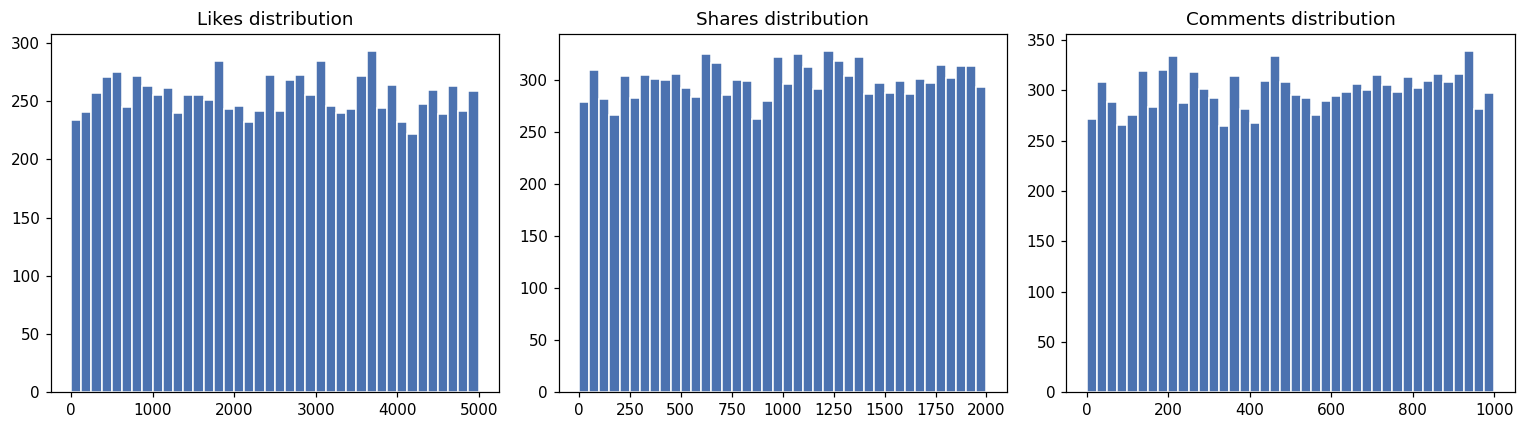

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["likes", "shares", "comments"]):
    ax.hist(posts_clean[col].dropna(), bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col.capitalize()} distribution")
plt.tight_layout()
plt.show()

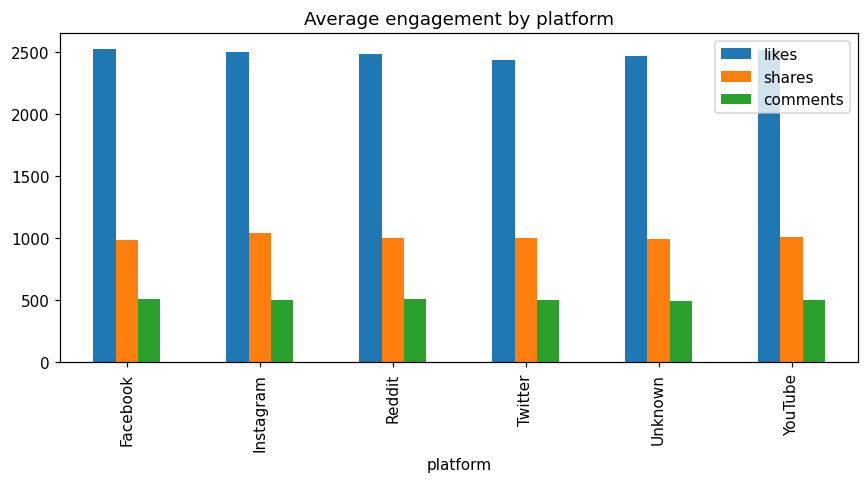

,likes,shares,comments
platform,,,
Facebook,2528.9,984.2,506.9
Instagram,2500.9,1040.8,499.8
Reddit,2488.1,1002.2,511.2
Twitter,2437.7,1005.4,506.1
Unknown,2475.1,998.6,496.5
YouTube,2517.8,1011.8,504.4


In [13]:
by_platform = posts_clean.groupby("platform")[["likes", "shares", "comments"]].mean().round(1)
by_platform.plot(kind="bar", figsize=(8, 4.5), title="Average engagement by platform")
plt.tight_layout()
plt.show()
by_platform

### Correlation check: does audience size or platform predict engagement?
This is the key insight-discovery question for this dataset.

In [14]:
corr_df = merged[["likes", "shares", "comments", "follower_count"]].corr()
corr_df

,likes,shares,comments,follower_count
likes,1.000000,-0.001246,0.010015,0.008230
shares,-0.001246,1.000000,0.024406,-0.014434
comments,0.010015,0.024406,1.000000,-0.000286
follower_count,0.008230,-0.014434,-0.000286,1.000000


**Finding:** correlations between `likes`, `shares`, `comments`, and `follower_count` are all near zero (≈ ±0.02). Engagement does not scale with audience size, and the three engagement metrics don't move together either — consistent with these values being randomly generated rather than organic user behavior. This is worth stating explicitly in the report as a property of the dataset, not a modeling failure.

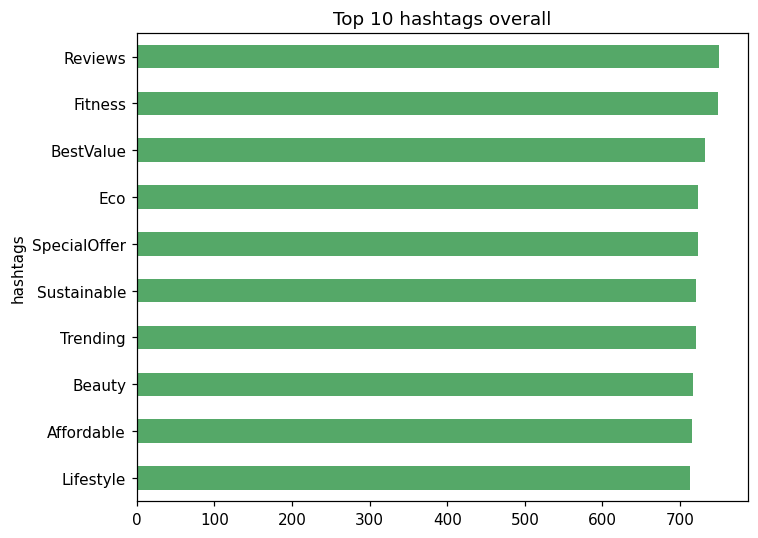

In [15]:
exploded = posts_clean.explode("hashtags").dropna(subset=["hashtags"])
top_hashtags = exploded["hashtags"].value_counts().head(10)
top_hashtags.plot(kind="barh", figsize=(7, 5), color="#55A868", title="Top 10 hashtags overall")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()